In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [8]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "training_set",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "test_set",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [9]:
import os

print("Training folders:", os.listdir("training_set"))
print("Testing folders:", os.listdir("test_set"))

Training folders: ['cats', 'dogs']
Testing folders: ['cats', 'dogs']


In [11]:
print(train_dataset.class_names)
print(test_dataset.class_names)

['cats', 'dogs']
['cats', 'dogs']


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\LAKSHDEEP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [15]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\LAKSHDEEP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 133s 520ms/step - accuracy: 0.6139 - loss: 0.6482 - val_accuracy: 0.6228 - val_loss: 0.6248
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 115s 457ms/step - accuracy: 0.7178 - loss: 0.5486 - val_accuracy: 0.7321 - val_loss: 0.5286
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 475ms/step - accuracy: 0.7801 - loss: 0.4644 - val_accuracy: 0.7617 - val_loss: 0.4986
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 475ms/step - accuracy: 0.8299 - loss: 0.3759 - val_accuracy: 0.7761 - val_loss: 0.5029
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 109s 435ms/step - accuracy: 0.8682 - loss: 0.3063 - val_accuracy: 0.7855 - val_loss: 0.5750
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 467ms/step - accuracy: 0.9111 - loss: 0.2199 - val_accuracy: 0.7795 - val_loss: 0.6681
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 474ms/step - accuracy: 0.9462 - loss: 0.1390 - val_accuracy: 0.7805 - val_loss: 0.8655
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 113s 451ms/step - accuracy: 0.9685 - loss: 0.08

In [18]:
model.save("cat_dog_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
🐶 Dog


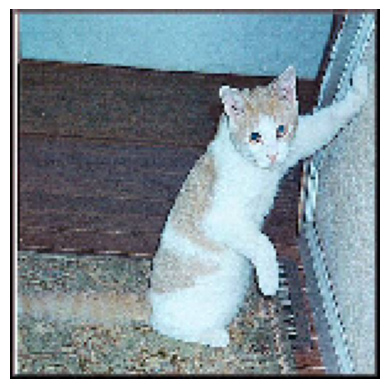

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img("test_set/cats/cat.4001.jpg", target_size=(150,150))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array/255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

In [30]:
img = image.load_img("test_set/dogs/dog.4001.jpg", target_size=(150,150))